# Практика 2

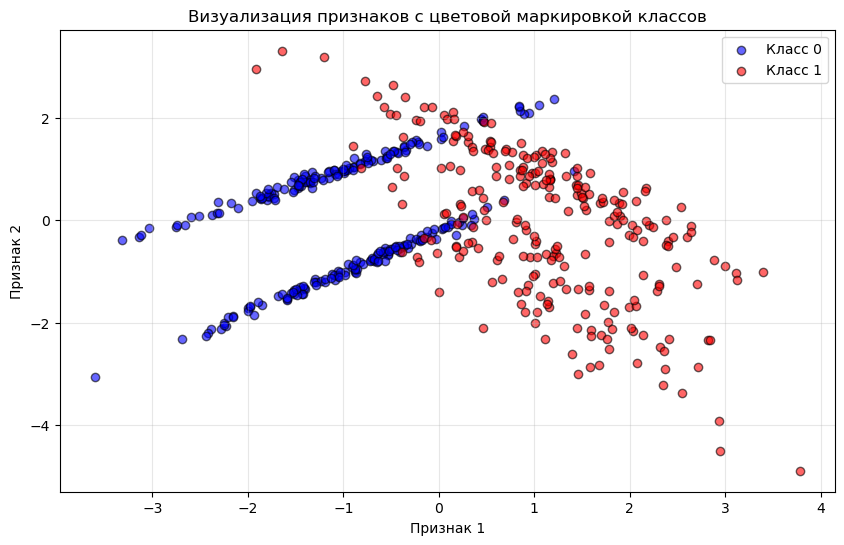

Ковариционая матрица для класса 0:
[[0.7613406  0.43813175]
 [0.43813175 1.25812197]]
Ковариционая матрица для класса 1:
[[ 0.89417292 -0.84232218]
 [-0.84232218  2.10035487]]


In [5]:
import numpy as np 
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt 



X, y = make_classification(n_samples  = 500 , 
                           n_features = 2, 
                           n_informative = 2 ,
                           n_redundant = 0,
                           n_clusters_per_class = 2 ,
                           flip_y= 0.01,
                           class_sep = 1.0,
                           random_state= 42)


plt.figure(figsize = ( 10 ,6))
plt.scatter(X[y == 0][:, 0], X[y ==0][:,1] , color = 'blue' , label = 'Класс 0', alpha = 0.6, edgecolor = 'k')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1],color = 'red', label = 'Класс 1', alpha= 0.6, edgecolor = 'k')


plt.title('Визуализация признаков с цветовой маркировкой классов')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha= 0.3)
plt.show()


for label in np.unique(y):
    class_data = X[y == label] 
    cov_matrix = np.cov(class_data.T)
    print(f'Ковариционая матрица для класса {label}:')
    print(cov_matrix)
    


In [11]:
from sklearn.model_selection import train_test_split 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis , QuadraticDiscriminantAnalysis


X_train ,X_test, y_train , y_test = train_test_split( X , y , test_size = 0.3, stratify = y , random_state = 42)

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()


lda.fit(X_train , y_train)
qda.fit(X_train, y_train)


lda_pred = lda.predict(X_test)
lda_prob = lda.predict_proba(X_test)

qda_pred = qda.predict(X_test)
qda_prob = qda.predict_proba(X_test)




print(lda_pred)
print(lda_prob)

print(qda_pred)
print(qda_prob)


[1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 0 1 0 0 1
 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0
 1 0 1 1 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0
 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 0 0 0 1 1 1 1 0 1 0 0
 1 0]
[[2.20308739e-01 7.79691261e-01]
 [3.28177975e-02 9.67182202e-01]
 [9.53045347e-01 4.69546533e-02]
 [4.42249704e-01 5.57750296e-01]
 [1.52984402e-04 9.99847016e-01]
 [9.08376271e-01 9.16237291e-02]
 [6.45998271e-01 3.54001729e-01]
 [1.92214366e-01 8.07785634e-01]
 [3.07759418e-02 9.69224058e-01]
 [2.49984744e-02 9.75001526e-01]
 [2.83577050e-02 9.71642295e-01]
 [5.11881260e-01 4.88118740e-01]
 [1.00928549e-01 8.99071451e-01]
 [6.50533914e-02 9.34946609e-01]
 [1.28654620e-01 8.71345380e-01]
 [3.81447028e-01 6.18552972e-01]
 [3.12012038e-02 9.68798796e-01]
 [4.36940030e-02 9.56305997e-01]
 [1.56597034e-03 9.98434030e-01]
 [4.70150332e-02 9.52984967e-01]
 [7.47586147e-02 9.25241385e-01]
 

In [13]:
from sklearn.metrics import accuracy_score, precision_score , recall_score, f1_score

def print_metrics(y_true, y_pred, name):
    print(f"--- Метрики для {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}\n")

print_metrics(y_test, lda_pred, "LDA")
print_metrics(y_test, qda_pred, "QDA")




from sklearn.metrics import confusion_matrix

print("Матрица LDA:\n", confusion_matrix(y_test, lda_pred))
print("Матрица QDA:\n", confusion_matrix(y_test, qda_pred))


--- Метрики для LDA ---
Accuracy:  0.8533
Precision: 0.8442
Recall:    0.8667
F1-score:  0.8553

--- Метрики для QDA ---
Accuracy:  0.8867
Precision: 0.8625
Recall:    0.9200
F1-score:  0.8903

Матрица LDA:
 [[63 12]
 [10 65]]
Матрица QDA:
 [[64 11]
 [ 6 69]]


In [17]:

X_small = X[:30]
y_small = y[:30]


reg_params = [0.0, 0.1, 0.5, 0.9]

results = []
for reg in reg_params:
    qda_reg = QuadraticDiscriminantAnalysis(reg_param=reg)
    qda_reg.fit(X_small, y_small)
    acc = qda_reg.score(X_test, y_test) 
    results.append(acc)
    print(f"reg_param={reg}: Accuracy = {acc:.4f}")

reg_param=0.0: Accuracy = 0.8733
reg_param=0.1: Accuracy = 0.8667
reg_param=0.5: Accuracy = 0.8667
reg_param=0.9: Accuracy = 0.8333
